# Exploratory Data Analysis (EDA)
## Travel Time Prediction Dataset

Notebook ini berisi visualisasi tambahan untuk memahami karakteristik data sebelum proses modeling.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
from google.colab import files

uploaded = files.upload()

df = pd.read_parquet(
    "AI_Engineer_dataset.parquet"
)

df["arrival_time"] = pd.to_datetime(
    df["arrival_time"]
)

Saving AI_Engineer_dataset.parquet to AI_Engineer_dataset.parquet


###Dataset Overview

In [3]:
print("Shape :", df.shape)

df.head()

Shape : (351103, 10)


,bus_body_no,segment_id,route_code,trip_id,stop_sequence,traveling_time_sec,from_arrival_time_str,arrival_time,average_time_sec,no_do
0,BUS-DUMMY-000213,SEG-DUMMY-008872,ROUTE-DUMMY-0001,TRIP-DUMMY-000012,19,219.803,2026-02-25 23:56:25,2026-02-26 00:00:04,270.049170,DO-DUMMY-00299173
1,BUS-DUMMY-000571,SEG-DUMMY-008870,ROUTE-DUMMY-0001,TRIP-DUMMY-000012,5,44.978,2026-02-25 23:59:21,2026-02-26 00:00:06,42.349785,DO-DUMMY-00299198
2,BUS-DUMMY-000587,SEG-DUMMY-009421,ROUTE-DUMMY-0001,TRIP-DUMMY-000012,16,52.956,2026-02-25 23:59:36,2026-02-26 00:00:29,47.706570,DO-DUMMY-00299184
3,BUS-DUMMY-000587,SEG-DUMMY-009422,ROUTE-DUMMY-0001,TRIP-DUMMY-000012,17,44.836,2026-02-26 00:01:10,2026-02-26 00:01:55,50.087549,DO-DUMMY-00299184
4,BUS-DUMMY-000222,SEG-DUMMY-008751,ROUTE-DUMMY-0001,TRIP-DUMMY-000013,19,154.996,2026-02-26 00:00:04,2026-02-26 00:02:39,157.195013,DO-DUMMY-00299174


###Missing Value Visualization

In [4]:
missing = df.isnull().sum()

missing

,0
bus_body_no,0
segment_id,0
route_code,0
trip_id,0
stop_sequence,0
traveling_time_sec,0
from_arrival_time_str,0
arrival_time,0
average_time_sec,0
no_do,0


### Insight

Tidak ditemukan missing value pada seluruh kolom sehingga tidak diperlukan proses imputasi.

###Travel Time Distribution

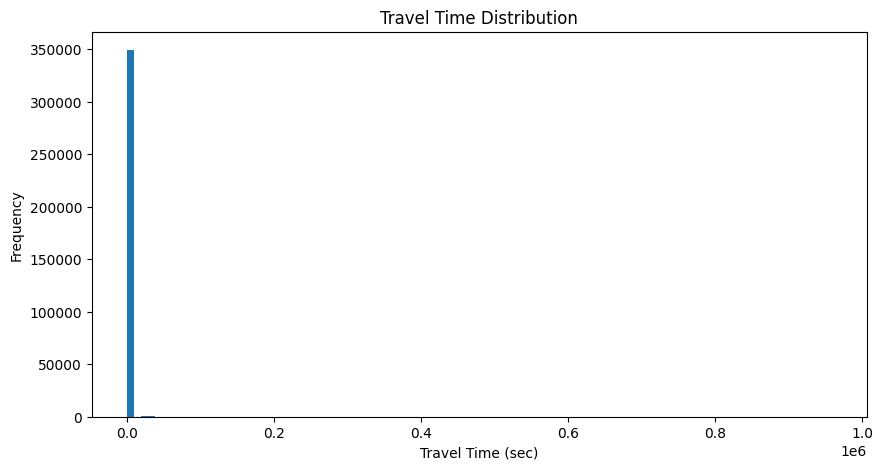

In [5]:
plt.figure(figsize=(10,5))

plt.hist(
    df["traveling_time_sec"],
    bins=100
)

plt.title(
    "Travel Time Distribution"
)

plt.xlabel(
    "Travel Time (sec)"
)

plt.ylabel(
    "Frequency"
)

plt.show()

###Log Distribution

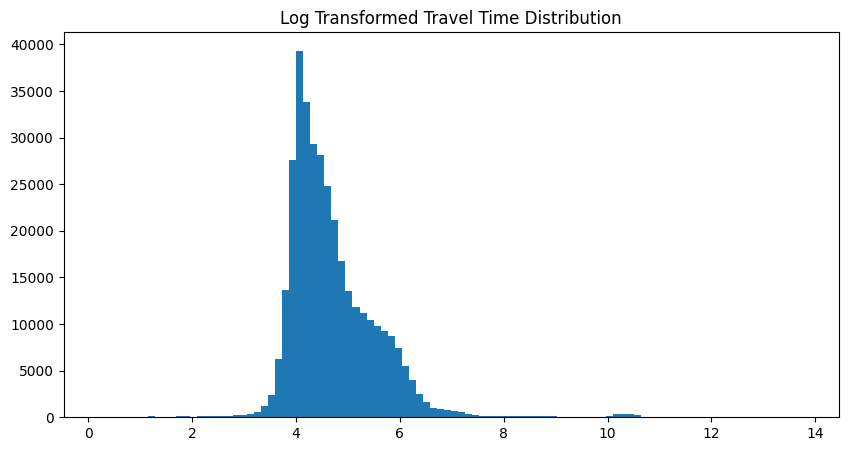

In [6]:
plt.figure(figsize=(10,5))

plt.hist(
    np.log1p(
        df["traveling_time_sec"]
    ),
    bins=100
)

plt.title(
    "Log Transformed Travel Time Distribution"
)

plt.show()

###Travel Time By Hour

In [7]:
df["hour"] = (
    df["arrival_time"]
      .dt.hour
)

hourly = (
    df.groupby("hour")
      ["traveling_time_sec"]
      .mean()
)

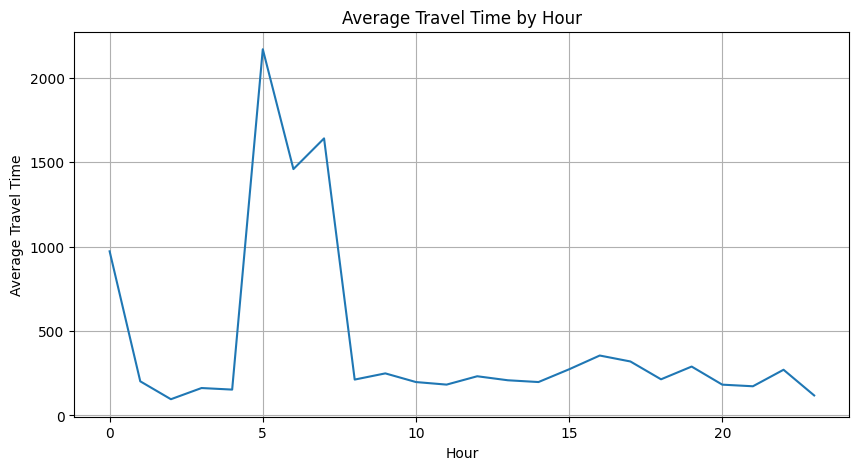

In [8]:
plt.figure(figsize=(10,5))

plt.plot(
    hourly.index,
    hourly.values
)

plt.title(
    "Average Travel Time by Hour"
)

plt.xlabel("Hour")
plt.ylabel("Average Travel Time")

plt.grid()

plt.show()

### Insight

Travel time cenderung meningkat pada jam operasional sibuk dan menurun pada jam sepi.

###Gap Detection

In [9]:
df = df.sort_values(
    ["trip_id","stop_sequence"]
)

df["seq_diff"] = (
    df.groupby("trip_id")
      ["stop_sequence"]
      .diff()
)

df["is_gap_suspected"] = (
    df["seq_diff"] > 1
).astype(int)

In [10]:
gap_count = (
    df["is_gap_suspected"]
      .value_counts()
)

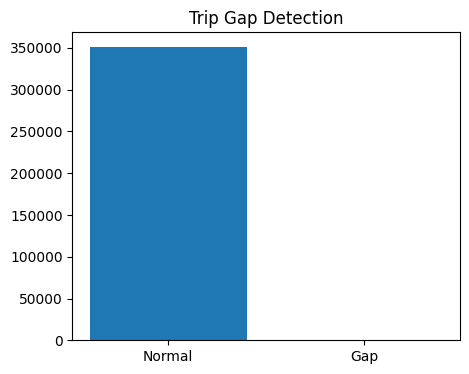

In [11]:
plt.figure(figsize=(5,4))

plt.bar(
    ["Normal","Gap"],
    gap_count.values
)

plt.title(
    "Trip Gap Detection"
)

plt.show()

### Insight

Hanya ditemukan 3 observasi gap sehingga dampaknya terhadap keseluruhan dataset sangat kecil.

###Segment Frequency

In [12]:
segment_freq = (
    df["segment_id"]
      .value_counts()
)

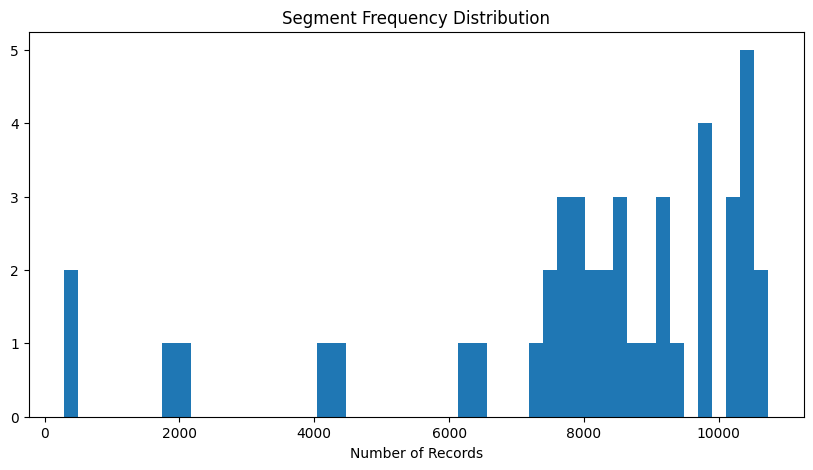

In [13]:
plt.figure(figsize=(10,5))

plt.hist(
    segment_freq,
    bins=50
)

plt.title(
    "Segment Frequency Distribution"
)

plt.xlabel(
    "Number of Records"
)

plt.show()

### Insight

Frekuensi segmen tidak merata. Beberapa segmen memiliki data historis jauh lebih banyak dibanding segmen lainnya sehingga diperlukan penanganan sparsity.

# Summary

## Temuan Utama

- Tidak ditemukan missing value.
- Distribusi travel time sangat skewed.
- Ditemukan outlier ekstrem.
- Hanya terdapat 3 kasus trip incompleteness.
- Terdapat sparsity pada beberapa segmen.

Hasil EDA ini digunakan sebagai dasar feature engineering dan pemilihan model prediksi travel time.